<a href="https://colab.research.google.com/github/Aarjav8055/ML-LAB/blob/main/LAB6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

KNN Accuracy: 0.9230769230769231
SVM Accuracy: 0.9230769230769231


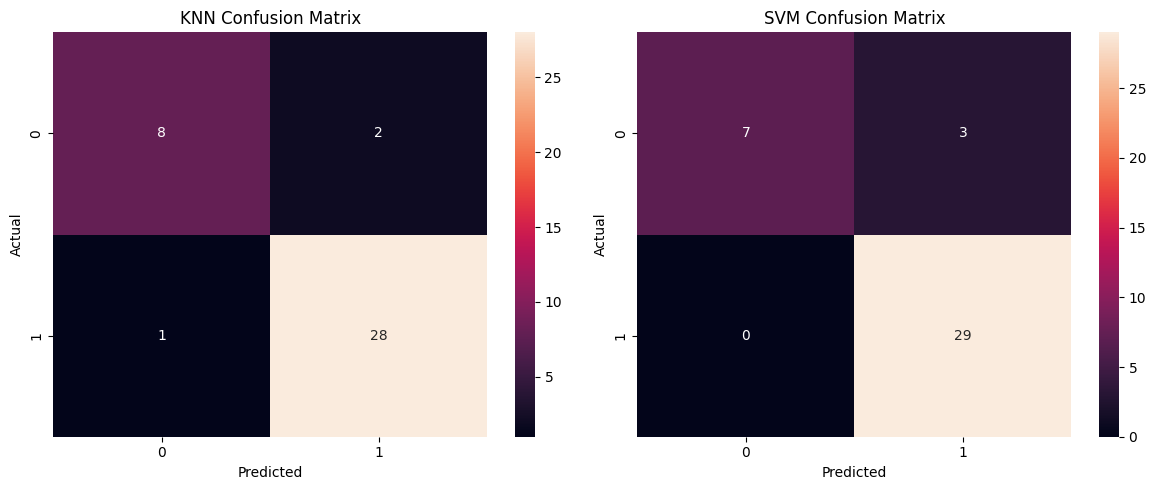

In [3]:
# =========================================
# 1. Import Libraries
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

import os

# =========================================
# 2. Load Dataset
# =========================================
if os.path.exists("/content/parkinsons.data"):
    df = pd.read_csv("/content/parkinsons.data")
else:
    print("Upload dataset first!")

# Drop 'name'
if "name" in df.columns:
    df.drop("name", axis=1, inplace=True)

# =========================================
# 3. Features & Target
# =========================================
X = df.drop("status", axis=1)
y = df["status"]

# =========================================
# 4. Train-Test Split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# 5. Scaling
# =========================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================
# 6. KNN Model
# =========================================
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# =========================================
# 7. SVM Model
# =========================================
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# =========================================
# 8. Accuracy
# =========================================
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

# =========================================
# 9. Confusion Matrices
# =========================================
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_svm = confusion_matrix(y_test, y_pred_svm)

# =========================================
# 10. Plotting (SIDE-BY-SIDE)
# =========================================
plt.figure(figsize=(12, 5))

# KNN Plot
plt.subplot(1, 2, 1)
sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# SVM Plot
plt.subplot(1, 2, 2)
sns.heatmap(cm_svm, annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()